In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('/content/placement.csv')

In [ ]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [ ]:
df.shape

(100, 4)

In [ ]:
df = df.iloc[:,1:]

In [ ]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [ ]:
import matplotlib.pyplot as plt

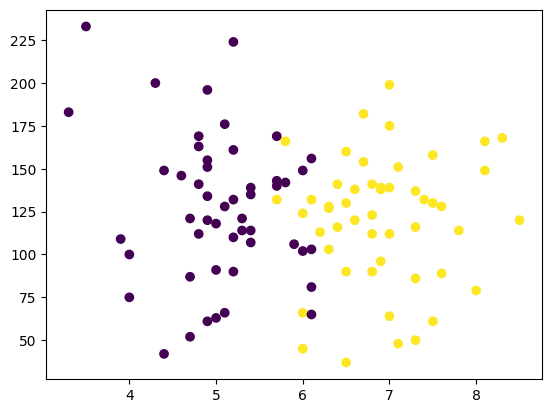

In [ ]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [ ]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [ ]:
x

,Unnamed: 0,cgpa
0,0,6.8
1,1,5.9
2,2,5.3
3,3,7.4
4,4,5.8
...,...,...
95,95,4.3
96,96,4.4
97,97,6.7
98,98,6.3


In [ ]:
y.shape

(100,)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1)

In [ ]:
x_train

,Unnamed: 0,cgpa
36,36,5.7
58,58,8.0
51,51,4.8
4,4,5.8
66,66,6.9
...,...,...
79,79,6.5
23,23,4.7
18,18,4.0
95,95,4.3


In [ ]:
y_train

,placement
36,0
58,1
51,0
4,0
66,1
...,...
79,1
23,0
18,0
95,0


In [ ]:
x_test

,Unnamed: 0,cgpa
93,93,6.8
88,88,4.4
49,49,5.4
31,31,3.9
80,80,4.9
32,32,7.0
22,22,4.9
38,38,6.5
91,91,7.5
34,34,4.8


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
x_train = scaler.fit_transform(x_train)

In [ ]:
x_train

array([[-0.44200343, -0.29609653],
       [ 0.31768996,  1.74696952],
       [ 0.07596934, -1.09555716],
       [-1.54701199, -0.20726757],
       [ 0.5939421 ,  0.76985098],
       [ 0.55941059,  1.83579848],
       [-0.54559798, -0.02960965],
       [ 0.42128452,  1.12516681],
       [ 0.17956389,  0.32570618],
       [-0.75278708, -0.02960965],
       [ 1.25004094, -0.20726757],
       [-0.2002828 ,  0.68102202],
       [ 1.21550942, -0.29609653],
       [-1.1671653 , -0.82907028],
       [-0.95997619,  0.94750889],
       [-0.99450771,  0.5033641 ],
       [-0.47653494,  0.68102202],
       [ 0.14503237,  2.0134564 ],
       [ 0.9737888 ,  1.12516681],
       [ 0.21409541,  1.5693116 ],
       [ 0.83566273, -1.0067282 ],
       [ 1.49176156, -0.74024132],
       [-0.02762521,  0.5033641 ],
       [ 0.386753  ,  0.76985098],
       [-1.02903923, -0.74024132],
       [ 0.45581603, -0.02960965],
       [-0.13121977, -0.02960965],
       [ 0.11050086,  0.85867993],
       [ 0.80113121,

In [ ]:
x_test = scaler.transform(x_test)

In [ ]:
x_test

array([[ 1.52629308,  0.68102202],
       [ 1.35363549, -1.45087299],
       [ 0.0069063 , -0.56258341],
       [-0.61466101, -1.89501779],
       [ 1.07738335, -1.0067282 ],
       [-0.5801295 ,  0.85867993],
       [-0.92544467, -1.0067282 ],
       [-0.37294039,  0.41453514],
       [ 1.45723005,  1.30282473],
       [-0.51106646, -1.09555716]])

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = LogisticRegression()

In [ ]:
clf.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred = clf.predict(x_test)

In [ ]:
y_test

,placement
93,1
88,0
49,0
31,0
80,0
32,1
22,0
38,1
91,1
34,0


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,y_pred)

1.0

In [ ]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

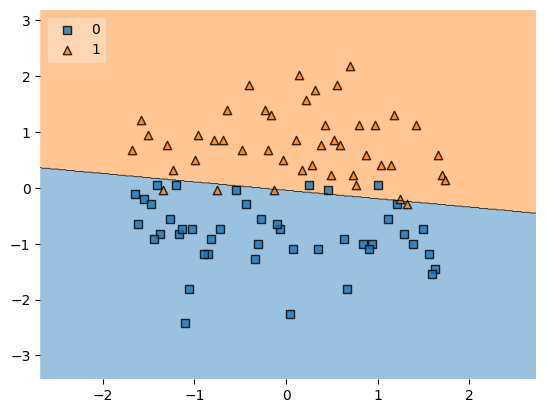

In [ ]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2 )

In [ ]:
import pickle

In [ ]:
pickle.dump(clf,open('model.pkl','wb'))